In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("Data.xlsx",engine="openpyxl")
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,40000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,30.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [3]:
df.shape

(10, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


In [5]:
df.isnull().sum()

Country      0
Age          1
Salary       1
Purchased    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Country', 'Age', 'Salary', 'Purchased'], dtype='object')

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9.0,37.888889,8.237786,27.0,30.0,37.0,44.0,50.0
Salary,9.0,62888.888889,13751.767563,40000.0,54000.0,61000.0,72000.0,83000.0


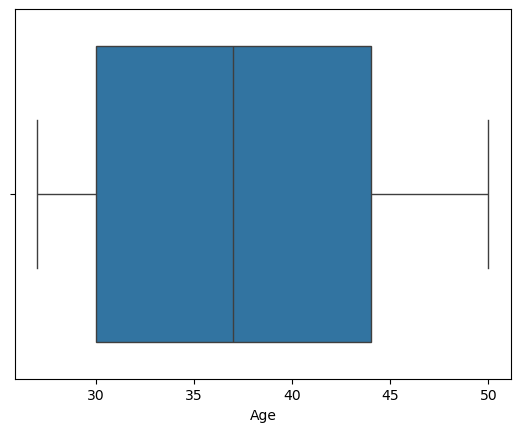

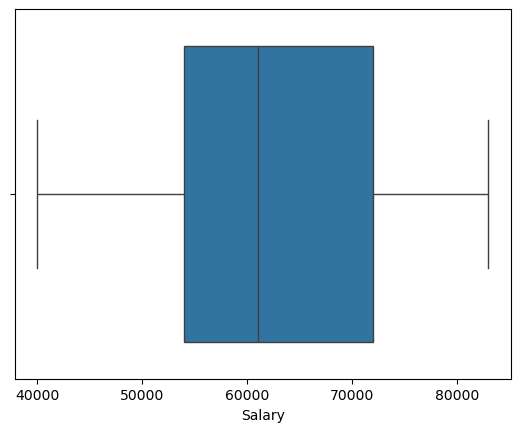

In [9]:
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [10]:
df.columns


Index(['Country', 'Age', 'Salary', 'Purchased'], dtype='object')

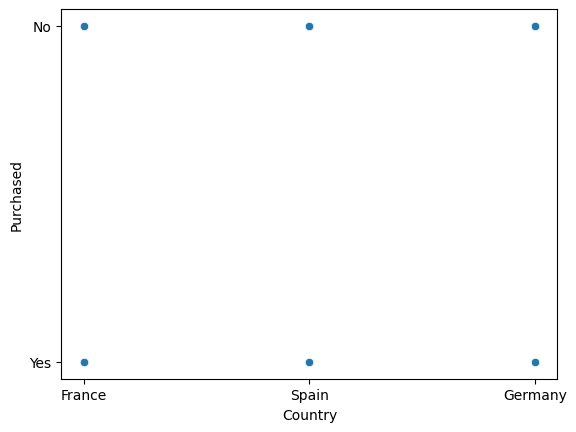

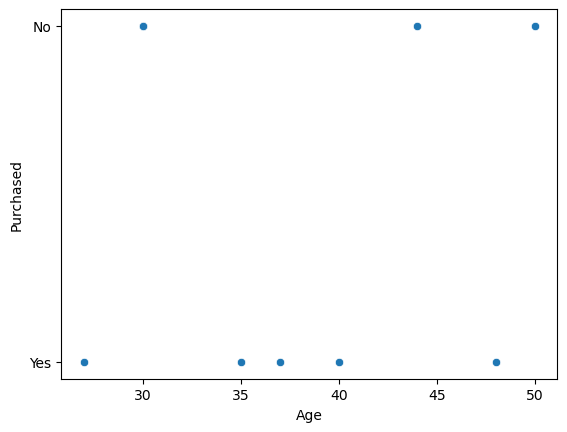

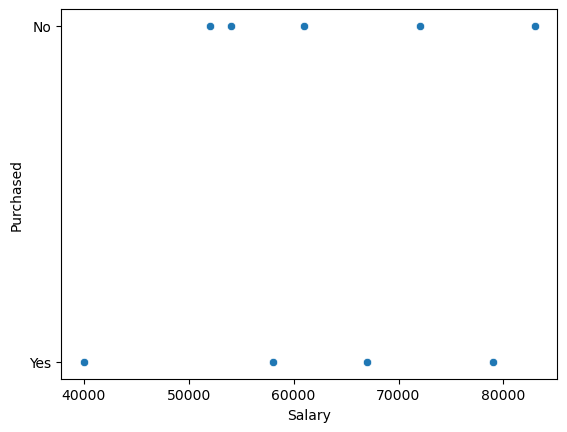

In [11]:
for i in ['Country','Age','Salary']:
    sns.scatterplot(data=df,x=i,y='Purchased')
    plt.show()

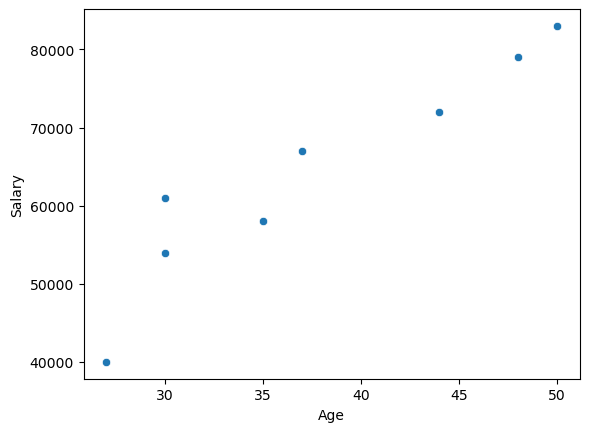

In [12]:
sns.scatterplot(data=df,x='Age',y='Salary')
plt.show()

In [13]:
s=df.select_dtypes(include='number').corr()
s

,Age,Salary
Age,1.000000,0.940047
Salary,0.940047,1.000000


<Figure size 1500x1500 with 0 Axes>

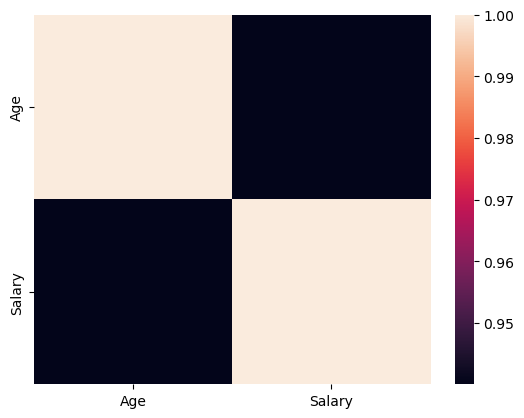

<Figure size 1500x1500 with 0 Axes>

In [14]:
sns.heatmap(s)
plt.figure(figsize=(15,15))

<Figure size 1500x1500 with 0 Axes>

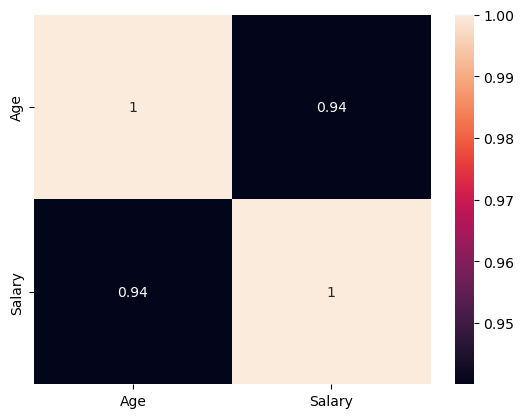

<Figure size 1500x1500 with 0 Axes>

In [15]:
sns.heatmap(s,annot=True)
plt.figure(figsize=(15,15))

In [16]:
df.isnull().sum()
for i in['Age','Salary']:
    df[i].fillna(df[i].median())

In [17]:
def wisker(col):
   q1,q3=np.percentile(col,[25,75])
   iqr=q3-q1
   lb=q1-1.25*iqr
   ub=q1+1.25*iqr
   return lb,ub
for i in ('Age','Salary'):
    lb,ub=wisker(df[i])
    df[i]=np.where(df[i]<lb,lb,df[i])
    df[i]=np.where(df[i]>ub,ub,df[i])
    df[i]

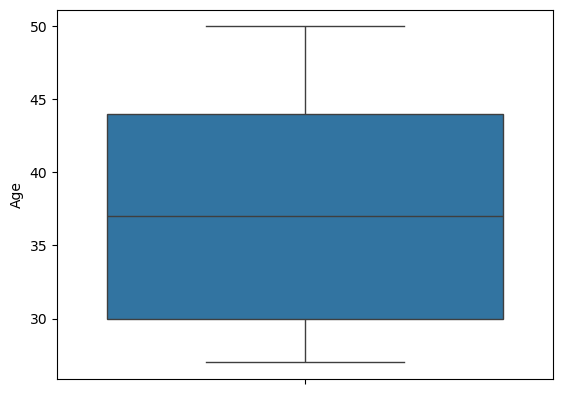

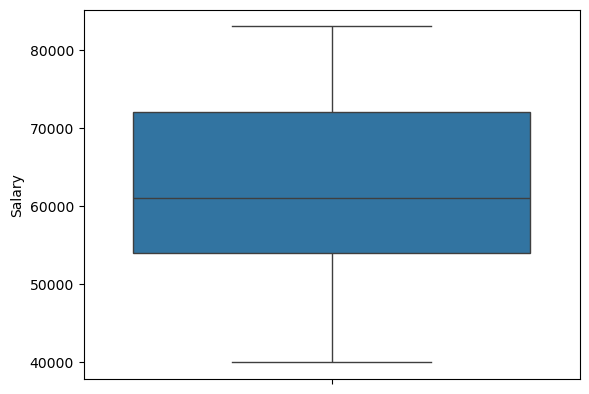

In [18]:
for i in['Age','Salary']:
    sns.boxplot(df[i])
    plt.show()

In [19]:
def wisker(col):
   q1,q3=np.percentile(col,[25,75])
   iqr=q3-q1
   lb=q1-1.25*iqr
   ub=q1+1.25*iqr
   return lb,ub
for i in ('Age','Salary'):
    lb,ub=wisker(df[i])
    df[i]=np.where(df[i]<lb,lb,df[i])
    df[i]=np.where(df[i]>ub,ub,df[i])

In [20]:
df[i]

0    72000.0
1    40000.0
2    54000.0
3    61000.0
4        NaN
5    58000.0
6    52000.0
7    79000.0
8    83000.0
9    67000.0
Name: Salary, dtype: float64

In [21]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
df['Country_name']=label_encoder.fit_transform(df['Country'])
df
label_encoder_y=LabelEncoder()
label_encoder_y.fit_transform(df['Purchased'])

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

In [23]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder=OneHotEncoder()
onehotencoder.fit_transform(df.Country.values.reshape(-1,1)).toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])